# MovieLens — Recommender System

**Final project — Business Decision-Making with Data**

*Laura Gomez Pena · Fernanda Marcos Gamez · Jose Juan Cortina Galindo*

---

## Context
We use the public **MovieLens** dataset (1995-2018, 100,836 ratings by 610 users on 9,742 movies) to study how to surface the right film for each user.

We split the project into two questions:

| Question | Type | Output |
|----------|------|--------|
| **Q1 - Recommendation** | Top-N ranking | Can we recommend films to a person? |
| **Q2 - Classification** | Binary supervised | Can we predict if a person will like a film? |

In [28]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF as SklearnNMF
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, mean_squared_error, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, train_test_split,
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)

# Visual style — Netflix-inspired
NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#221F1F"
GREEN = "#46D369"
BLUE = "#4A90E2"
sns.set_style("whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

PALETTE = {
    "primary": "#E50914",     # netflix red
    "secondary": "#221F1F",   # near-black
    "accent": "#564D4D",
    "muted": "#B3B3B3",
    "good": "#46D369",
    "bad": "#E50914",
    "blue": "#1F77B4",
}


---

## 1. Data loading and preprocessing

We start from two CSVs (`ratings.csv` and `movies.csv`) and engineer additional features.


In [22]:
DATA_DIR = "ml-latest-small"

ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies = pd.read_csv(os.path.join(DATA_DIR, "movies.csv"))

ratings = ratings.rename(columns={"userId": "user_id", "movieId": "movie_id"})
movies = movies.rename(columns={"movieId": "movie_id"})

print(f"Total ratings : {len(ratings):,}")
print(f"Unique users  : {ratings['user_id'].nunique():,}")
print(f"Unique movies : {ratings['movie_id'].nunique():,}")
print(f"Null values   : {ratings.isna().sum().sum() + movies.isna().sum().sum()}")
print(f"Duplicates    : {ratings.duplicated().sum() + movies.duplicated().sum()}")
ratings.head()

Total ratings : 100,836
Unique users  : 610
Unique movies : 9,724
Null values   : 0
Duplicates    : 0


,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### 1.1 Movie features (genres + year)

One hot encode genre and extract year from title. 

In [52]:
def extract_year(title):
    if not isinstance(title, str):
        return None
    m = re.search(r"\((\d{4})\)\s*$", title.strip())
    return int(m.group(1)) if m else None


movies["year"] = movies["title"].apply(extract_year)
movies["year"] = movies["year"].fillna(movies["year"].median())

genre_dummies = movies["genres"].fillna("").str.get_dummies(sep="|")
if "(no genres listed)" in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(columns=["(no genres listed)"])
genre_dummies.columns = [f"genre_{c}" for c in genre_dummies.columns]
genre_columns = list(genre_dummies.columns)

movies = pd.concat([movies, genre_dummies], axis=1)
movies[["movie_id", "title", "year"] + genre_columns[:5]].head()

,movie_id,title,year,genre_Action,genre_Action,genre_Adventure,genre_Adventure,genre_Animation,genre_Animation,genre_Children,genre_Children,genre_Comedy,genre_Comedy
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,1,1,1,1
1,2,Jumanji (1995),1995.0,0,0,1,1,0,0,1,1,0,0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,0,0,0,1,1
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,0,0,0,1,1
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,0,0,0,1,1


### 1.2 Leave-last-out split

Test only contains last movie seen by each user

In [24]:
def leave_last_out_split(ratings, min_ratings_per_user=2):
    counts = ratings.groupby("user_id").size()
    valid = counts[counts >= min_ratings_per_user].index
    df = ratings[ratings["user_id"].isin(valid)].sort_values(["user_id", "timestamp"])
    last = df.groupby("user_id").tail(1).index
    test = df.loc[last].reset_index(drop=True)
    train = df.drop(last).reset_index(drop=True)
    return train, test


train_ratings, test_ratings = leave_last_out_split(ratings)
print(f"Train ratings : {len(train_ratings):,}  ({len(train_ratings) / len(ratings):.1%})")
print(f"Test ratings  : {len(test_ratings):,}  ({len(test_ratings) / len(ratings):.1%})")
print(f"One held-out movie per user -> {test_ratings['user_id'].nunique()} users in test")

Train ratings : 100,226  (99.4%)
Test ratings  : 610  (0.6%)
One held-out movie per user -> 610 users in test


### 1.3 Train-only statistics

`user_avg`, `user_count`, `movie_avg`, `movie_count` and the `global_mean`
are computed **on the training set only**.

In [25]:
global_mean = float(train_ratings["rating"].mean())

user_stats = train_ratings.groupby("user_id").agg(
    user_avg=("rating", "mean"),
    user_count=("rating", "count"),
)

movie_stats = train_ratings.groupby("movie_id").agg(
    movie_avg=("rating", "mean"),
    movie_count=("rating", "count"),
)

print(f"Global mean rating: {global_mean:.3f}")
print(f"Users with stats  : {len(user_stats):,}")
print(f"Movies with stats : {len(movie_stats):,}")

Global mean rating: 3.500
Users with stats  : 610
Movies with stats : 9,701


### 1.4 User-user similarity score

For each `(user, movie)` pair we compute the similarity-weighted average of
ratings from the user's most similar peers who have rated that movie. 

In [26]:
TOP_K_SIMILAR = 10

user_movie = train_ratings.pivot_table(
    index="user_id", columns="movie_id", values="rating", aggfunc="mean"
)
R = user_movie.fillna(0.0).values
M = (~user_movie.isna()).astype(float).values

sim = cosine_similarity(R)
np.fill_diagonal(sim, 0.0)

# Keep top-K neighbours per user
n_users = sim.shape[0]
k = min(TOP_K_SIMILAR, n_users - 1)
small = np.argsort(sim, axis=1)[:, : n_users - k]
rows = np.repeat(np.arange(n_users), small.shape[1])
cols = small.flatten()
sim[rows, cols] = 0.0

num = sim @ R
den = sim @ M
with np.errstate(divide="ignore", invalid="ignore"):
    score = np.where(den > 0, num / den, np.nan)

user_sim_df = pd.DataFrame(score, index=user_movie.index, columns=user_movie.columns)
user_sim_lookup = (
    user_sim_df.stack(future_stack=True)
    .dropna()
    .rename("user_sim_score")
    .reset_index()
)
print(f"user_sim_score lookup: {len(user_sim_lookup):,} rows")

user_sim_score lookup: 741,985 rows


### 1.5 NMF latent factors

We factorise the user x movie matrix with non-negative matrix factorisation
(`k = 50` latent components). The reconstructed matrix `R-hat = W H` gives a
collaborative-filtering score for **every** `(user, movie)` pair, including
items the user has never rated.

In [7]:
NMF_COMPONENTS = 50

mat = user_movie.fillna(0.0).values
nmf_model = SklearnNMF(
    n_components=NMF_COMPONENTS,
    init="nndsvd",
    random_state=42,
    max_iter=500,
)
W = nmf_model.fit_transform(mat)
H = nmf_model.components_
pred = W @ H

pred_df = pd.DataFrame(pred, index=user_movie.index, columns=user_movie.columns)
nmf_lookup = (
    pred_df.stack(future_stack=True)
    .dropna()
    .rename("nmf_score")
    .reset_index()
)

print(f"W shape: {W.shape}   H shape: {H.shape}")
print(f"Reconstruction error : {nmf_model.reconstruction_err_:.2f}")
print(f"nmf_score lookup     : {len(nmf_lookup):,} rows")

W shape: (610, 50)   H shape: (50, 9701)
Reconstruction error : 771.74
nmf_score lookup     : 5,917,610 rows


### 1.6 Assemble feature matrices

Add new features to train and test data.

In [8]:
def add_features(df, movies, user_stats, movie_stats, global_mean,
                 user_sim_lookup, genre_columns, nmf_lookup):
    df = df.copy()
    df = df.merge(user_stats, on="user_id", how="left")
    df = df.merge(movie_stats, on="movie_id", how="left")
    df = df.merge(movies[["movie_id", "year"] + genre_columns], on="movie_id", how="left")
    df = df.merge(user_sim_lookup, on=["user_id", "movie_id"], how="left")
    df = df.merge(nmf_lookup, on=["user_id", "movie_id"], how="left")

    df["user_avg"]       = df["user_avg"].fillna(global_mean)
    df["movie_avg"]      = df["movie_avg"].fillna(global_mean)
    df["user_count"]     = df["user_count"].fillna(0)
    df["movie_count"]    = df["movie_count"].fillna(0)
    df["user_sim_score"] = df["user_sim_score"].fillna(global_mean)
    df["nmf_score"]      = df["nmf_score"].fillna(global_mean)
    df[genre_columns]    = df[genre_columns].fillna(0)
    df["year"]           = df["year"].fillna(movies["year"].median())

    df["interaction"] = df["user_avg"] * df["movie_avg"]
    df["diff"]        = df["user_avg"] - df["movie_avg"]
    df["abs_diff"]    = df["diff"].abs()
    return df


train_fe = add_features(train_ratings, movies, user_stats, movie_stats,
                        global_mean, user_sim_lookup, genre_columns, nmf_lookup)
test_fe = add_features(test_ratings, movies, user_stats, movie_stats,
                       global_mean, user_sim_lookup, genre_columns, nmf_lookup)

base_features = [
    "user_avg", "user_count", "movie_avg", "movie_count",
    "interaction", "abs_diff", "user_sim_score", "nmf_score", "year",
]
feature_columns = base_features + genre_columns

X_train = train_fe[feature_columns].copy()
X_test  = test_fe[feature_columns].copy()

print(f"Feature columns: {len(feature_columns)}")
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

Feature columns: 28
X_train: (100226, 28)   X_test: (610, 28)


---

## 2. Exploratory data analysis

### 2.1 Dataset quality and dimensions

In [9]:
quality = pd.DataFrame({
    "Metric": ["Null values", "Duplicates", "Total ratings", "Unique users",
               "Unique movies", "Final feature columns"],
    "Value":  [int(train_fe.isna().sum().sum() + test_fe.isna().sum().sum()),
               int(ratings.duplicated().sum() + movies.duplicated().sum()),
               len(ratings),
               ratings["user_id"].nunique(),
               ratings["movie_id"].nunique(),
               len(feature_columns)],
})
quality

,Metric,Value
0,Null values,0
1,Duplicates,0
2,Total ratings,100836
3,Unique users,610
4,Unique movies,9724
5,Final feature columns,28


### 2.2 Rating distribution

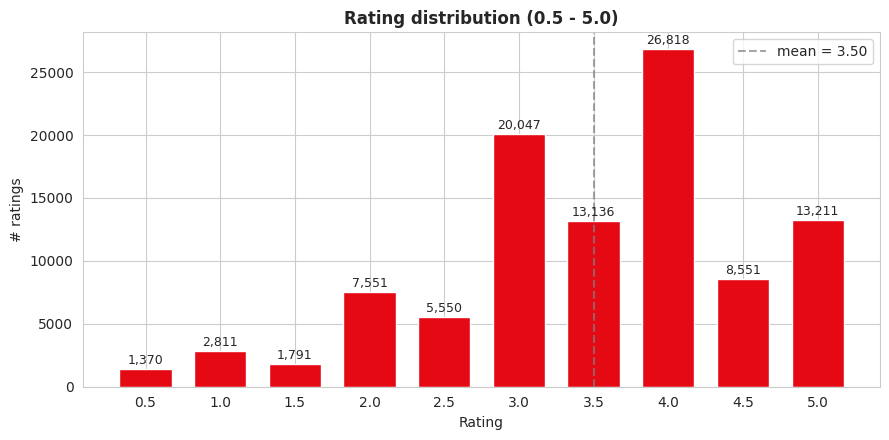

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
counts = ratings["rating"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=NETFLIX_RED, width=0.7)
ax.axvline(x=str(3.5), color="grey", linestyle="--", alpha=0.7,
           label=f"mean = {ratings['rating'].mean():.2f}")
for i, v in enumerate(counts.values):
    ax.text(i, v + 400, f"{v:,}", ha="center", fontsize=9)
ax.set_title("Rating distribution (0.5 - 5.0)")
ax.set_xlabel("Rating")
ax.set_ylabel("# ratings")
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Class balance for Q2 (binary target)

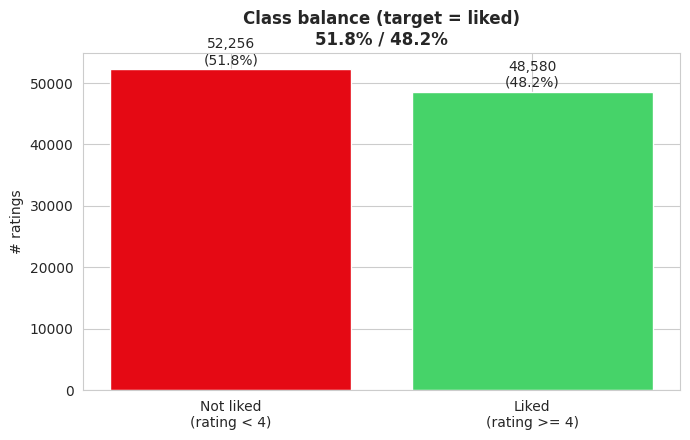

In [11]:
liked = (ratings["rating"] >= 4).astype(int)
counts = liked.value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["Not liked\n(rating < 4)", "Liked\n(rating >= 4)"], counts.values,
       color=[NETFLIX_RED, GREEN])
for i, v in enumerate(counts.values):
    ax.text(i, v + 800, f"{v:,}\n({pct.iloc[i]:.1f}%)", ha="center", fontsize=10)
ax.set_title(f"Class balance (target = liked)\n{pct.iloc[0]:.1f}% / {pct.iloc[1]:.1f}%")
ax.set_ylabel("# ratings")
plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap


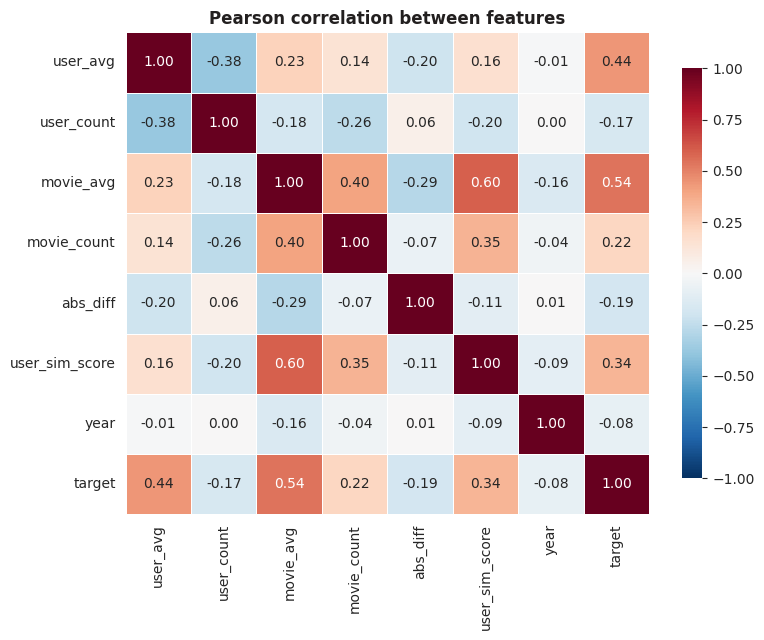

In [12]:
heatmap_features = ["user_avg", "user_count", "movie_avg", "movie_count",
                    "abs_diff", "user_sim_score", "year"]

heat_df = train_fe[heatmap_features + ["rating"]].rename(columns={"rating": "target"})
corr = heat_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=False, linewidths=0.5,
            cbar_kws={"shrink": 0.85}, ax=ax)
ax.set_title("Pearson correlation between features", color=NETFLIX_BLACK)
plt.tight_layout()
plt.show()

### 2.4 Distribution per genre and per year. 

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000

movies with a single rating: 3446 (35.4%)
movies with < 10 ratings:    7455 (76.7%)
movies with >= 100 ratings:  138


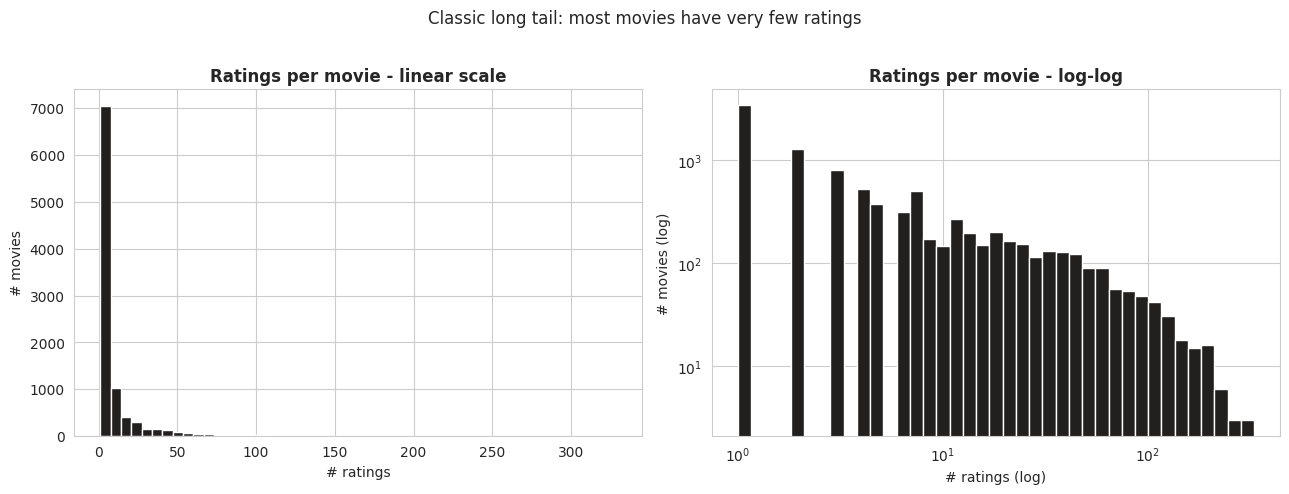

In [30]:
per_movie = ratings.groupby("movie_id").size()

print(per_movie.describe().to_string())

print(
    f"\nmovies with a single rating: {(per_movie == 1).sum()} "
    f"({100 * (per_movie == 1).sum() / len(per_movie):.1f}%)"
)

print(
    f"movies with < 10 ratings:    {(per_movie < 10).sum()} "
    f"({100 * (per_movie < 10).sum() / len(per_movie):.1f}%)"
)

print(
    f"movies with >= 100 ratings:  {(per_movie >= 100).sum()}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# =========================
# Linear scale
# =========================
axes[0].hist(
    per_movie,
    bins=50,
    color=PALETTE["secondary"],
    edgecolor="white"
)

axes[0].set_title("Ratings per movie - linear scale")
axes[0].set_xlabel("# ratings")
axes[0].set_ylabel("# movies")

# =========================
# Log-log scale
# =========================
bins_log = np.logspace(0, np.log10(per_movie.max() + 1), 40)

axes[1].hist(
    per_movie,
    bins=bins_log,
    color=PALETTE["secondary"],
    edgecolor="white"
)

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Ratings per movie - log-log")
axes[1].set_xlabel("# ratings (log)")
axes[1].set_ylabel("# movies (log)")

fig.suptitle(
    "Classic long tail: most movies have very few ratings",
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.show()

Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87


Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87


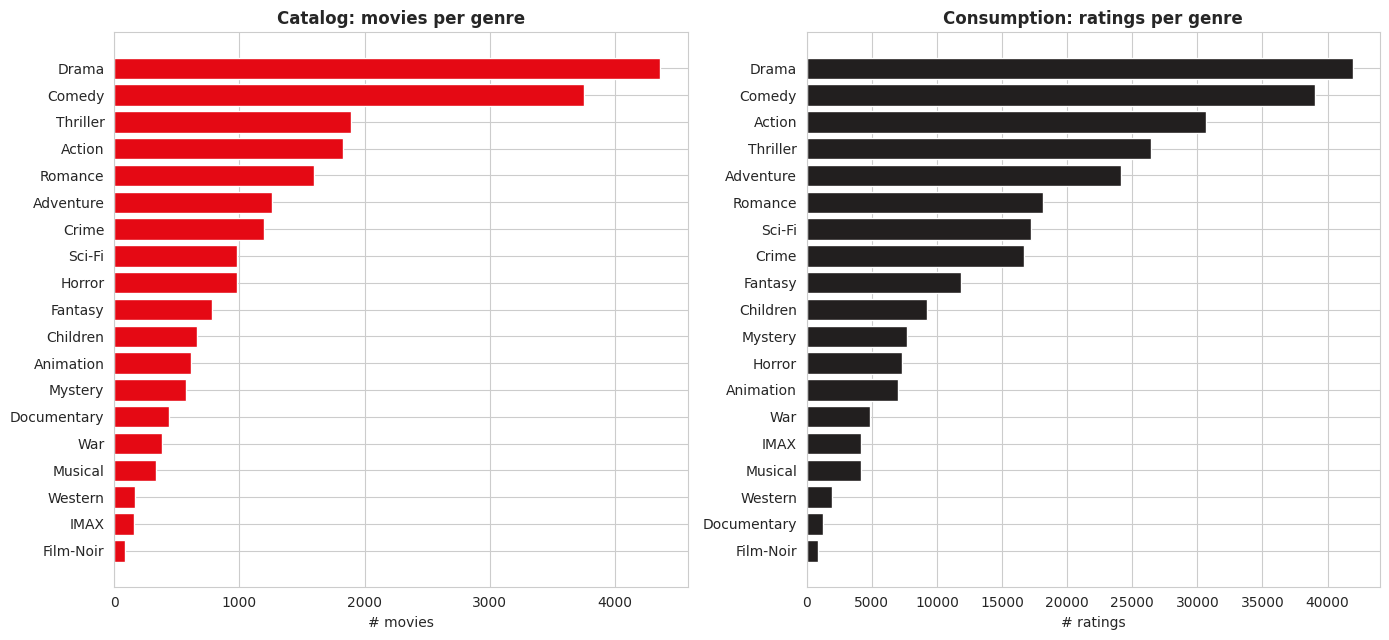

In [33]:
genre_counts = movies[genre_columns].sum().sort_values(ascending=False)
genre_counts.index = [c.replace("genre_", "") for c in genre_counts.index]

print(genre_counts.to_string())

# Combine with ratings: rating volume per genre (consumption)
ratings_with_genre = ratings.merge(
    movies[["movie_id"] + genre_columns],
    on="movie_id",
    how="left"
)

rated_per_genre = (
    ratings_with_genre[genre_columns]
    .sum()
    .sort_values(ascending=False)
)

rated_per_genre.index = [c.replace("genre_", "") for c in rated_per_genre.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

# =========================
# Catalog: movies per genre
# =========================
axes[0].barh(
    genre_counts.index[::-1],
    genre_counts.values[::-1],
    color=PALETTE["primary"],
    edgecolor="white"
)

axes[0].set_title("Catalog: movies per genre")
axes[0].set_xlabel("# movies")

# =========================
# Consumption: ratings per genre
# =========================
axes[1].barh(
    rated_per_genre.index[::-1],
    rated_per_genre.values[::-1],
    color=PALETTE["secondary"],
    edgecolor="white"
)

axes[1].set_title("Consumption: ratings per genre")
axes[1].set_xlabel("# ratings")

plt.tight_layout()
plt.show()

---

## 4. Q1 - Recommendation: can we recommend films to a person?

Top-10 ranking with NMF + linear calibration.

### 4.1 Why Linear Regression and the Neural Network fail at ranking

**First approach.** Predict exact ratings with Ridge and an MLP, evaluate
with RMSE. Both reach RMSE close to 1. When we evaluate the same models with **Hit@10**, the metric
collapses below 0.10.

**Final approach: NMF.** Non-negative matrix factorisation learns latent
factors directly from the user x movie rating matrix. Each user and each
movie becomes a `k = 50`-dimensional vector.

### 4.2 Hit@10 metric

In [13]:
def hit_rate_at_k(true_items, pred_items, k):
    true_set = set(true_items)
    return float(any(item in true_set for item in pred_items[:k]))


def precision_at_k(true_items, pred_items, k):
    if k <= 0 or len(pred_items) == 0:
        return 0.0
    true_set = set(true_items)
    hits = sum(1 for item in pred_items[:k] if item in true_set)
    return hits / k


def recall_at_k(true_items, pred_items, k):
    true_set = set(true_items)
    if not true_set:
        return 0.0
    hits = sum(1 for item in pred_items[:k] if item in true_set)
    return hits / len(true_set)


def ndcg_at_k(pred_items, k, true_relevance):
    if not true_relevance:
        return 0.0
    def dcg(rels):
        return sum((2.0 ** r - 1) / np.log2(i + 2) for i, r in enumerate(rels))
    gains = [true_relevance.get(m, 0.0) for m in pred_items[:k]]
    ideal = sorted(true_relevance.values(), reverse=True)[:k]
    idcg = dcg(ideal)
    return dcg(gains) / idcg if idcg > 0 else 0.0

### 4.3 Building candidate features for unseen movies

To rank, we need to score `(user, movie)` pairs the user has never rated.
This helper rebuilds the feature row for those pairs from the precomputed
lookups (so `nmf_score` and `user_sim_score` come straight from the trained
NMF and user-similarity matrices).

In [14]:
def build_candidate_features(user_id, candidate_movie_ids):
    df = pd.DataFrame({"user_id": user_id, "movie_id": candidate_movie_ids})
    return add_features(df, movies, user_stats, movie_stats, global_mean,
                        user_sim_lookup, genre_columns, nmf_lookup)


def evaluate_ranker(model, X_train, y_train, k=10, max_users=None,
                    candidate_strategy="test_plus_sample", task="regression",
                    liked_threshold=4.0, verbose=False, seed=42):
    test = test_fe.copy()
    relevant = test[test["rating"] >= liked_threshold]
    users = relevant["user_id"].unique()
    if max_users is not None:
        users = users[:max_users]

    rng = np.random.default_rng(seed)
    all_movies = movies["movie_id"].unique()

    hits, precs, recs, ndcgs = [], [], [], []

    for i, uid in enumerate(users):
        liked = relevant[relevant["user_id"] == uid]
        true_items = liked["movie_id"].tolist()
        true_rel = dict(zip(liked["movie_id"], liked["rating"]))
        if not true_items:
            continue

        if candidate_strategy == "test_plus_sample":
            seen = train_ratings.loc[train_ratings["user_id"] == uid, "movie_id"].unique()
            pool = np.setdiff1d(all_movies, np.union1d(seen, true_items))
            n_neg = min(99, len(pool))
            negatives = rng.choice(pool, size=n_neg, replace=False)
            cands = np.concatenate([np.array(true_items), negatives])
        else:  # 'unseen'
            seen = train_ratings.loc[train_ratings["user_id"] == uid, "movie_id"].unique()
            cands = np.setdiff1d(all_movies, seen)

        cdf = build_candidate_features(uid, cands)
        Xc = cdf[feature_columns]
        if task == "classification" and hasattr(model, "predict_proba"):
            scores = model.predict_proba(Xc)[:, 1]
        else:
            scores = model.predict(Xc)

        order = np.argsort(-scores)
        ranked = cdf.iloc[order]["movie_id"].tolist()

        hits.append(hit_rate_at_k(true_items, ranked, k))
        precs.append(precision_at_k(true_items, ranked, k))
        recs.append(recall_at_k(true_items, ranked, k))
        ndcgs.append(ndcg_at_k(ranked, k, true_rel))

        if verbose and (i + 1) % 100 == 0:
            print(f"  [eval] {i + 1}/{len(users)} users")

    return {
        "hit@k":       float(np.mean(hits)) if hits else 0.0,
        "precision@k": float(np.mean(precs)) if precs else 0.0,
        "recall@k":    float(np.mean(recs)) if recs else 0.0,
        "ndcg@k":      float(np.mean(ndcgs)) if ndcgs else 0.0,
        "n_users":     len(hits),
    }

### 4.4 The NMF ranker (with linear calibration)

NMF's reconstructed score lives on an arbitrary scale, not the [0, 5] rating
range, we add a linear regression that maps `rating ~= a * nmf_score + b` to fix this. 

In [15]:
class NMFRanker:
    def __init__(self, task="regression"):
        self.task = task
        self.calibrator = LinearRegression()

    def fit(self, X, y):
        self.calibrator.fit(X[["nmf_score"]], y)
        return self

    def predict(self, X):
        scores = self.calibrator.predict(X[["nmf_score"]])
        return np.clip(scores, 0.0, 5.0)

    def predict_proba(self, X):
        scores = self.predict(X)
        p = np.clip(scores / 5.0, 0.0, 1.0)
        return np.column_stack([1.0 - p, p])

### 4.5 Q1 hyperparameter tuning (3-fold CV on train, neg RMSE scoring)

In [16]:
y_train_reg = train_fe["rating"].astype(float)
y_test_reg  = test_fe["rating"].astype(float)

ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(early_stopping=True, max_iter=200, random_state=42)),
])

ridge_search = RandomizedSearchCV(
    ridge_pipe,
    {"model__alpha": [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]},
    n_iter=6, scoring="neg_root_mean_squared_error", cv=3,
    n_jobs=-1, random_state=42,
)
ridge_search.fit(X_train, y_train_reg)
print(f"Ridge       best CV RMSE = {-ridge_search.best_score_:.4f}   {ridge_search.best_params_}")

mlp_search = RandomizedSearchCV(
    mlp_pipe,
    {
        "model__hidden_layer_sizes": [(32,), (64, 32), (32, 16)],
        "model__alpha": [1e-4, 1e-3, 0.01, 0.1],
        "model__learning_rate_init": [1e-3, 5e-3, 0.01],
    },
    n_iter=10, scoring="neg_root_mean_squared_error", cv=3,
    n_jobs=-1, random_state=42,
)
mlp_search.fit(X_train, y_train_reg)
print(f"MLP         best CV RMSE = {-mlp_search.best_score_:.4f}   {mlp_search.best_params_}")

Ridge       best CV RMSE = 0.7741   {'model__alpha': 1000.0}
MLP         best CV RMSE = 0.7103   {'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.1}


### 4.6 Train final models and evaluate both heads (RMSE + Hit@10)

In [18]:
ridge_final = ridge_search.best_estimator_
mlp_final   = mlp_search.best_estimator_
nmf_final   = NMFRanker(task="regression").fit(X_train, y_train_reg)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

q1_results = {}
for name, model in [("Linear Regression (Ridge)", ridge_final),
                    ("MLP", mlp_final),
                    ("NMF (calibrated)", nmf_final)]:
    yhat = model.predict(X_test)
    rm   = rmse(y_test_reg, yhat)
    yhat_train = model.predict(X_train)
    rm_train = rmse(y_train_reg, yhat_train)
    rk   = evaluate_ranker(model, X_train, y_train_reg, k=10,
                           candidate_strategy="test_plus_sample",
                           task="regression")
    q1_results[name] = {"RMSE (train)": rm_train, "RMSE (test)": rm, "Hit@10": rk["hit@k"],
                        "n_users": rk["n_users"]}
    print(f"{name:28s}  RMSE (train) = {rm_train:.3f}   RMSE (test) = {rm:.3f}   Hit@10 = {rk['hit@k']:.3f}   "
          f"(n_users = {rk['n_users']})")

Linear Regression (Ridge)     RMSE (train) = 0.772   RMSE (test) = 1.004   Hit@10 = 0.124   (n_users = 363)
MLP                           RMSE (train) = 0.702   RMSE (test) = 1.090   Hit@10 = 0.085   (n_users = 363)
NMF (calibrated)              RMSE (train) = 0.991   RMSE (test) = 1.196   Hit@10 = 0.760   (n_users = 363)


---

## 5. Q2 - Classification: can we predict if a person will like a film?

Binary classification with `liked = (rating >= 4)`.

80/20 Split for this classification task

In [36]:
y_class_full = (pd.concat([train_fe["rating"], test_fe["rating"]]) >= 4).astype(int)
X_class_full = pd.concat([X_train, X_test]).reset_index(drop=True)
y_class_full = y_class_full.reset_index(drop=True)

# Drop nmf_score and interaction for a fair supervised comparison
X_class_full = X_class_full.drop(columns=["nmf_score", "interaction"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_class_full, y_class_full, test_size=0.20, random_state=42,
    stratify=y_class_full,
)
print(f"X_tr: {X_tr.shape}   X_te: {X_te.shape}")
print(f"Class balance (train): {y_tr.value_counts(normalize=True).round(3).to_dict()}")
print(f"Class balance (test) : {y_te.value_counts(normalize=True).round(3).to_dict()}")

X_tr: (80668, 26)   X_te: (20168, 26)
Class balance (train): {0: 0.518, 1: 0.482}
Class balance (test) : {0: 0.518, 1: 0.482}


### 5.2 Hyperparameter tuning (GridSearchCV, 3-fold CV on the 80% train, scoring = ROC AUC)

In [37]:
log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
gbm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier(random_state=42)),
])
mlp_clf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(early_stopping=True, max_iter=300, random_state=42)),
])

log_search = GridSearchCV(
    log_pipe, {"model__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="roc_auc", cv=3, n_jobs=-1,
).fit(X_tr, y_tr)
print(f"LogReg  best CV AUC = {log_search.best_score_:.4f}   {log_search.best_params_}")

gbm_search = GridSearchCV(
    gbm_pipe,
    {
        "model__n_estimators": [50, 100],
        "model__max_depth":    [3, 5],
        "model__learning_rate":[0.05, 0.1],
        "model__subsample":    [0.8, 1.0],
    },
    scoring="roc_auc", cv=3, n_jobs=-1,
).fit(X_tr, y_tr)
print(f"GBM     best CV AUC = {gbm_search.best_score_:.4f}   {gbm_search.best_params_}")

mlp_search_clf = RandomizedSearchCV(
    mlp_clf_pipe,
    {
        "model__hidden_layer_sizes": [(32,), (64, 32), (32, 16)],
        "model__alpha": [1e-4, 1e-3, 0.01, 0.1],
        "model__learning_rate_init": [1e-3, 5e-3, 0.01],
    },
    n_iter=10, scoring="roc_auc", cv=3,
    n_jobs=-1, random_state=42,
).fit(X_tr, y_tr)
print(f"MLP     best CV AUC = {mlp_search_clf.best_score_:.4f}   {mlp_search_clf.best_params_}")

LogReg  best CV AUC = 0.8139   {'model__C': 0.1}
GBM     best CV AUC = 0.8309   {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
MLP     best CV AUC = 0.8160   {'model__learning_rate_init': 0.005, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.1}


### 5.3 Final test-set evaluation: ROC curves and confusion matrices

In [43]:
log_final = log_search.best_estimator_
gbm_final = gbm_search.best_estimator_
mlp_final_clf = mlp_search_clf.best_estimator_

q2_results = {}
proba_per_model = {}
pred_per_model = {}

for name, model in [("Logistic Regression", log_final),
                    ("Gradient Boosting", gbm_final),
                    ("MLP", mlp_final_clf)]:
    yhat = model.predict(X_te)
    yp   = model.predict_proba(X_te)[:, 1]
    auc  = roc_auc_score(y_te, yp)
    q2_results[name] = {
        "Accuracy":  accuracy_score(y_te, yhat),
        "Precision": precision_score(y_te, yhat),
        "Recall":    recall_score(y_te, yhat),
        "F1":        f1_score(y_te, yhat),
        "ROC AUC":   auc,
    }
    proba_per_model[name] = yp
    pred_per_model[name]  = yhat
    print(f"{name:22s}  AUC = {auc:.3f}   Acc = {accuracy_score(y_te, yhat):.3f}")

q2_table = pd.DataFrame(q2_results).T.round(3)
q2_table

Logistic Regression     AUC = 0.814   Acc = 0.737
Gradient Boosting       AUC = 0.834   Acc = 0.750
MLP                     AUC = 0.818   Acc = 0.738


Logistic Regression     AUC = 0.814   Acc = 0.737
Gradient Boosting       AUC = 0.834   Acc = 0.750
MLP                     AUC = 0.818   Acc = 0.738


,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.737,0.723,0.734,0.729,0.814
Gradient Boosting,0.750,0.739,0.745,0.742,0.834
MLP,0.738,0.738,0.709,0.723,0.818


In [41]:
log_final = log_search.best_estimator_
gbm_final = gbm_search.best_estimator_
mlp_final_clf = mlp_search_clf.best_estimator_

q2_results = {}
proba_per_model = {}
pred_per_model = {}

proba_per_model_tr = {}
pred_per_model_tr = {}

for name, model in [
    ("Logistic Regression", log_final),
    ("Gradient Boosting", gbm_final),
    ("MLP", mlp_final_clf)
]:
    # =========================
    # TEST
    # =========================
    yhat_te = model.predict(X_te)
    yp_te = model.predict_proba(X_te)[:, 1]
    auc_te = roc_auc_score(y_te, yp_te)

    # =========================
    # TRAIN
    # =========================
    yhat_tr = model.predict(X_tr)
    yp_tr = model.predict_proba(X_tr)[:, 1]
    auc_tr = roc_auc_score(y_tr, yp_tr)

    q2_results[name] = {
        "Accuracy (train)": accuracy_score(y_tr, yhat_tr),
        "Precision (train)": precision_score(y_tr, yhat_tr),
        "Recall (train)": recall_score(y_tr, yhat_tr),
        "F1 (train)": f1_score(y_tr, yhat_tr),
        "ROC AUC (train)": auc_tr,

        "Accuracy (test)": accuracy_score(y_te, yhat_te),
        "Precision (test)": precision_score(y_te, yhat_te),
        "Recall (test)": recall_score(y_te, yhat_te),
        "F1 (test)": f1_score(y_te, yhat_te),
        "ROC AUC (test)": auc_te,
    }

    proba_per_model[name] = yp_te
    pred_per_model[name] = yhat_te

    proba_per_model_tr[name] = yp_tr
    pred_per_model_tr[name] = yhat_tr

    print(
        f"{name:22s}  "
        f"Train AUC = {auc_tr:.3f}   Train Acc = {accuracy_score(y_tr, yhat_tr):.3f}   |   "
        f"Test AUC = {auc_te:.3f}   Test Acc = {accuracy_score(y_te, yhat_te):.3f}"
    )

q2_table = pd.DataFrame(q2_results).T.round(3)
q2_table

Logistic Regression     Train AUC = 0.814   Train Acc = 0.735   |   Test AUC = 0.814   Test Acc = 0.737
Gradient Boosting       Train AUC = 0.845   Train Acc = 0.759   |   Test AUC = 0.834   Test Acc = 0.750
MLP                     Train AUC = 0.820   Train Acc = 0.740   |   Test AUC = 0.818   Test Acc = 0.738


Logistic Regression     Train AUC = 0.814   Train Acc = 0.735   |   Test AUC = 0.814   Test Acc = 0.737
Gradient Boosting       Train AUC = 0.845   Train Acc = 0.759   |   Test AUC = 0.834   Test Acc = 0.750
MLP                     Train AUC = 0.820   Train Acc = 0.740   |   Test AUC = 0.818   Test Acc = 0.738


,Accuracy (train),Precision (train),Recall (train),F1 (train),ROC AUC (train),Accuracy (test),Precision (test),Recall (test),F1 (test),ROC AUC (test)
Logistic Regression,0.735,0.719,0.737,0.728,0.814,0.737,0.723,0.734,0.729,0.814
Gradient Boosting,0.759,0.743,0.765,0.754,0.845,0.750,0.739,0.745,0.742,0.834
MLP,0.740,0.736,0.717,0.726,0.820,0.738,0.738,0.709,0.723,0.818


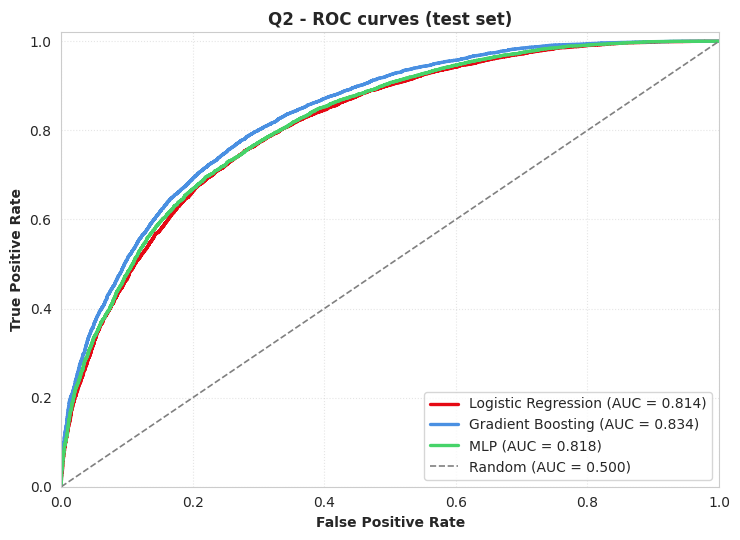

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = {"Logistic Regression": NETFLIX_RED,
          "Gradient Boosting":   BLUE,
          "MLP":                 GREEN}

for name, yp in proba_per_model.items():
    fpr, tpr, _ = roc_curve(y_te, yp)
    auc = q2_results[name]["ROC AUC"]
    ax.plot(fpr, tpr, color=colors[name], linewidth=2.4,
            label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.2,
        label="Random (AUC = 0.500)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate", fontweight="bold")
ax.set_ylabel("True Positive Rate", fontweight="bold")
ax.set_title("Q2 - ROC curves (test set)")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

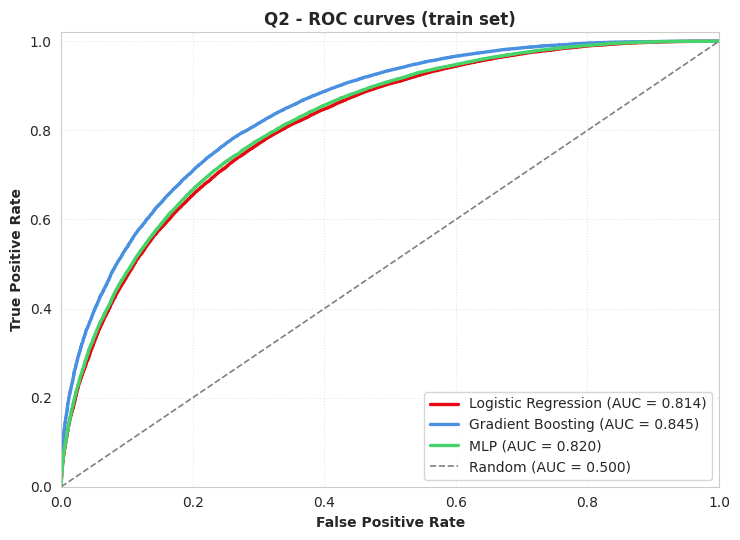

In [ ]:
# =========================
# ROC CURVES - TRAIN
# =========================
fig, ax = plt.subplots(figsize=(7.5, 5.5))

colors = {
    "Logistic Regression": NETFLIX_RED,
    "Gradient Boosting": BLUE,
    "MLP": GREEN
}

for name, yp_tr in proba_per_model_tr.items():
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, yp_tr)
    auc_tr = roc_auc_score(y_tr, yp_tr)

    ax.plot(
        fpr_tr,
        tpr_tr,
        color=colors[name],
        linewidth=2.4,
        label=f"{name} (AUC = {auc_tr:.3f})"
    )

ax.plot(
    [0, 1],
    [0, 1],
    color="grey",
    linestyle="--",
    linewidth=1.2,
    label="Random (AUC = 0.500)"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate", fontweight="bold")
ax.set_ylabel("True Positive Rate", fontweight="bold")
ax.set_title("Q2 - ROC curves (Train)")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

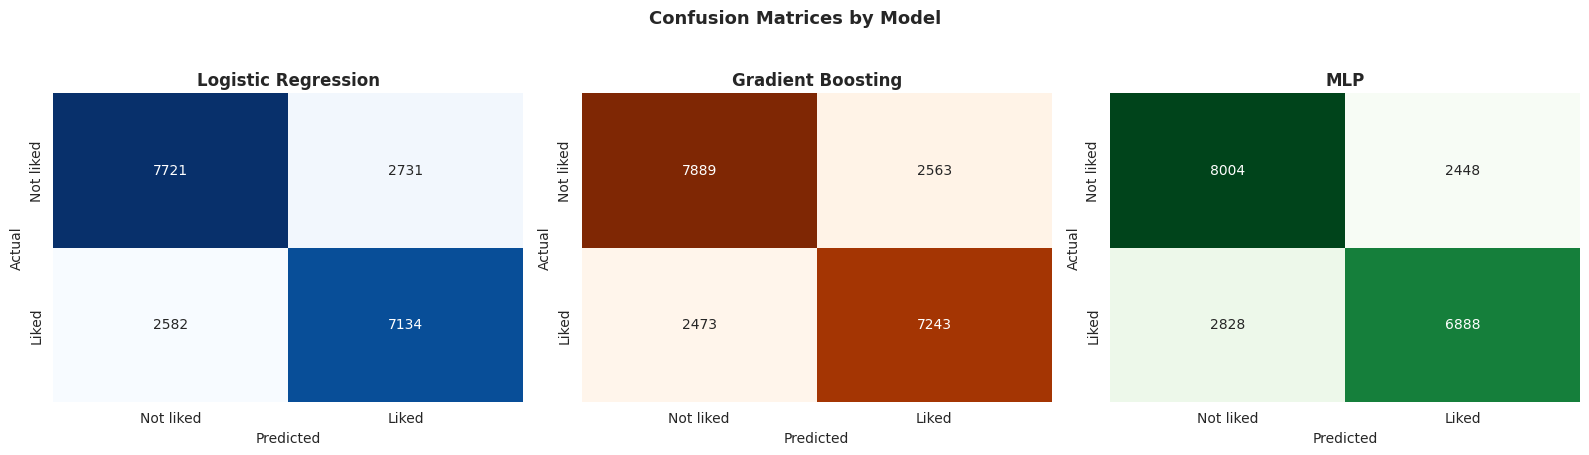

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
cmaps = {"Logistic Regression": "Blues",
         "Gradient Boosting":   "Oranges",
         "MLP":                 "Greens"}

for ax, (name, yhat) in zip(axes, pred_per_model.items()):
    cm = confusion_matrix(y_te, yhat)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmaps[name],
                xticklabels=["Not liked", "Liked"],
                yticklabels=["Not liked", "Liked"],
                ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

fig.suptitle("Confusion Matrices by Model", fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

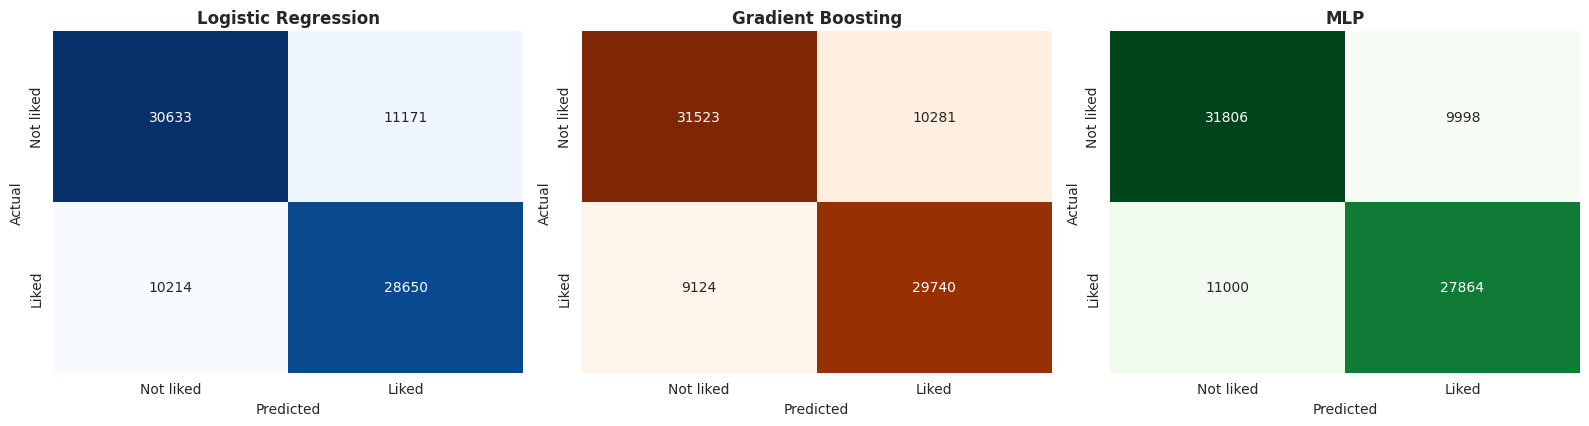

In [51]:
# =========================
# CONFUSION MATRICES - TRAIN
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

cmaps = {
    "Logistic Regression": "Blues",
    "Gradient Boosting": "Oranges",
    "MLP": "Greens"
}

for ax, (name, yhat_tr) in zip(axes, pred_per_model_tr.items()):
    cm = confusion_matrix(y_tr, yhat_tr)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmaps[name],
        xticklabels=["Not liked", "Liked"],
        yticklabels=["Not liked", "Liked"],
        ax=ax,
        cbar=False
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()